In [1]:
!pip install kagglehub scikit-fuzzy matplotlib seaborn -q opencv-python
print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 22.0 MB/s eta 0:00:00
All libraries installed!


In [2]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [4]:
import kagglehub

path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)
print("Dataset path:", path)
print("Folders:", os.listdir(path))

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset path: /kaggle/input/brain-tumor-mri-dataset
Folders: ['Training', 'Testing']


In [5]:
# Find correct subdirectory
for root, dirs, files in os.walk(path):
    if 'Training' in dirs:
        dataset_path = root
        break

train_dir = os.path.join(dataset_path, 'Training')
test_dir  = os.path.join(dataset_path, 'Testing')

print("Train dir:", train_dir)
print("Test dir: ", test_dir)
print("Classes:", os.listdir(train_dir))

Train dir: /kaggle/input/brain-tumor-mri-dataset/Training
Test dir:  /kaggle/input/brain-tumor-mri-dataset/Testing
Classes: ['pituitary', 'notumor', 'meningioma', 'glioma']


In [6]:
IMG_SIZE = (224, 224)
BATCH = 16   # ↓ reduce memory load

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='categorical',
    shuffle=False
)

CLASS_NAMES = train_ds.class_names

# Normalize
from tensorflow.keras.applications.efficientnet import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y)).prefetch(tf.data.AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Extract labels from dataset
y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_labels = np.argmax(y_train, axis=1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)

class_weights = dict(enumerate(class_weights))

print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0)}


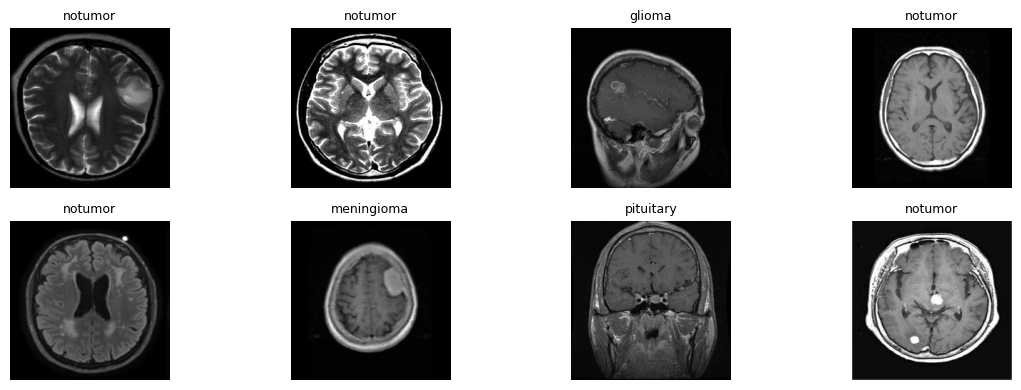

In [8]:
plt.figure(figsize=(12, 4))
for images, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(2, 4, i+1)

        img = images[i].numpy()
        img = (img - img.min()) / (img.max() - img.min())  # FIX
        plt.imshow(img)
        label_idx = np.argmax(labels[i])
        plt.title(CLASS_NAMES[label_idx], fontsize=9)
        plt.axis('off')

plt.tight_layout()
plt.show()

In [22]:
from tensorflow.keras.applications import EfficientNetB0  # lighter model

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    data_aug,  # 👈 important
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weights
)

print("Training done!")

Epoch 1/25


In [ ]:
loss, acc = model.evaluate(val_ds, verbose=0)
print(f"Final test accuracy: {acc*100:.2f}%")

# Plot accuracy and loss
all_acc = history1.history['accuracy']
all_val = history1.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(all_acc, label='train accuracy')
plt.plot(all_val, label='val accuracy')

plt.title('Accuracy'); plt.legend(); plt.grid(True, alpha=0.3)

all_loss = history1.history['loss']
all_vloss = history1.history['val_loss']

plt.subplot(1, 2, 2)
plt.plot(all_loss, label='train loss')
plt.plot(all_vloss, label='val loss')
plt.title('Loss'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

In [ ]:
# Fuzzy system: takes CNN confidence → gives human-readable risk level

confidence_var = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'confidence')
risk_var        = ctrl.Consequent(np.arange(0, 101, 1), 'risk')

# Define membership functions for confidence
confidence_var['low']    = fuzz.trimf(confidence_var.universe, [0,   0,   0.4])
confidence_var['medium'] = fuzz.trimf(confidence_var.universe, [0.3, 0.55, 0.75])
confidence_var['high']   = fuzz.trimf(confidence_var.universe, [0.65, 1.0, 1.0])

# Define membership functions for risk output
risk_var['low']    = fuzz.trimf(risk_var.universe, [0,   0,  40])
risk_var['medium'] = fuzz.trimf(risk_var.universe, [25, 50, 75])
risk_var['high']   = fuzz.trimf(risk_var.universe, [60, 100, 100])

# Rules: if CNN says high confidence tumor → high risk
rules = [
    ctrl.Rule(confidence_var['low'],    risk_var['low']),
    ctrl.Rule(confidence_var['medium'], risk_var['medium']),
    ctrl.Rule(confidence_var['high'],   risk_var['high']),
]

fuzzy_ctrl   = ctrl.ControlSystem(rules)
fuzzy_system = ctrl.ControlSystemSimulation(fuzzy_ctrl)

def get_fuzzy_risk(confidence_score):
    fuzzy_system.input['confidence'] = float(confidence_score)
    fuzzy_system.compute()
    return fuzzy_system.output['risk']

# Test it
for val in [0.3, 0.6, 0.9]:
    risk = get_fuzzy_risk(val)
    print(f"CNN confidence {val:.0%} → Fuzzy risk score: {risk:.1f}/100")
print("Fuzzy system ready!")

In [ ]:
def predict_mri(image_path):
    # Load and preprocess image
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    # CNN prediction
    probs       = model.predict(arr, verbose=0)[0]
    class_idx   = np.argmax(probs)
    confidence  = float(probs[class_idx])
    class_label = CLASS_NAMES[class_idx]

    # Fuzzy confidence → risk score
    risk_score = get_fuzzy_risk(confidence) if class_label != 'notumor' else 0.0

    # Display
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(tf.keras.utils.load_img(image_path))
    plt.title(f"Prediction: {class_label}\nConfidence: {confidence:.1%}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    colors = ['#ef4444' if i == class_idx else '#94a3b8' for i in range(4)]
    plt.barh(CLASS_NAMES, probs, color=colors)
    plt.xlim(0, 1); plt.xlabel('Probability')
    plt.title(f"Fuzzy Risk Score: {risk_score:.0f}/100")
    plt.tight_layout(); plt.show()

    return {'class': class_label, 'confidence': confidence,
            'all_probs': dict(zip(CLASS_NAMES, probs.tolist())),
            'fuzzy_risk': risk_score}

print("predict_mri() function ready!")

In [ ]:
from google.colab import files

# Save class names so Streamlit knows the labels
import json
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

# Download both files
files.download('best_model.keras')
files.download('class_names.json')
print("Done! Check your Downloads folder.")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
import cv2

def show_gradcam(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)

    # preprocess same as training
    from tensorflow.keras.applications.efficientnet import preprocess_input
    img_array_exp = preprocess_input(img_array_exp)

    heatmap = make_gradcam_heatmap(img_array_exp, model)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)

    # Superimpose
    jet = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = jet * 0.4 + img_array

    # Plot
    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed.astype("uint8"))
    plt.title("Grad-CAM")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
y_pred_probs = []

for images, _ in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_pred_probs = np.array(y_pred_probs)

# Plot ROC for each class
plt.figure(figsize=(8,6))

for i in range(4):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()